In [2]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


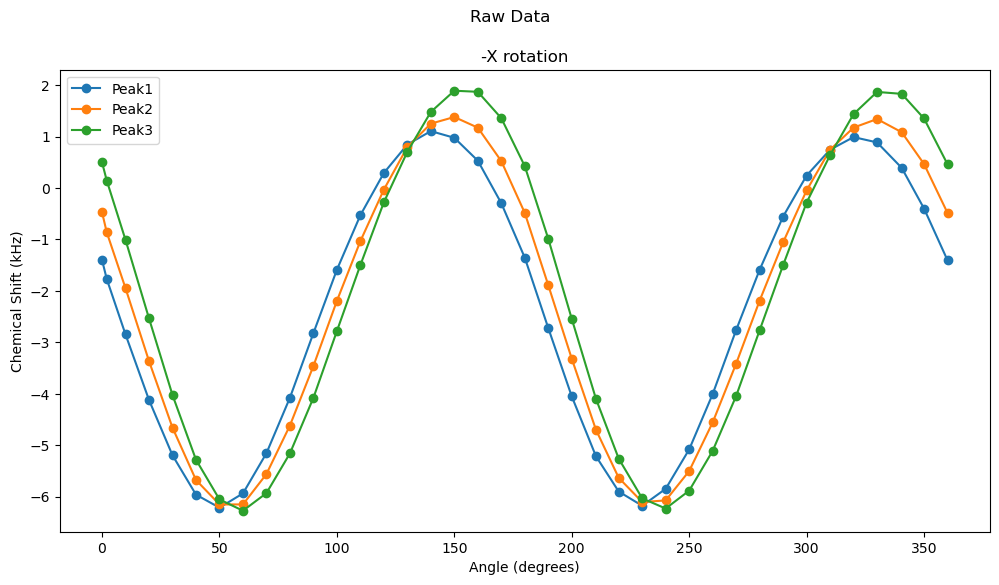

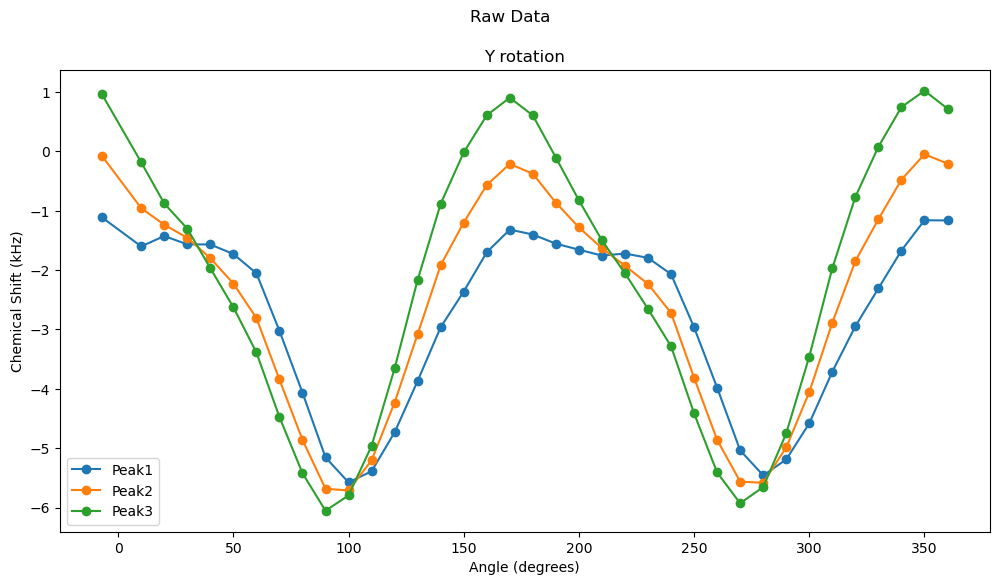

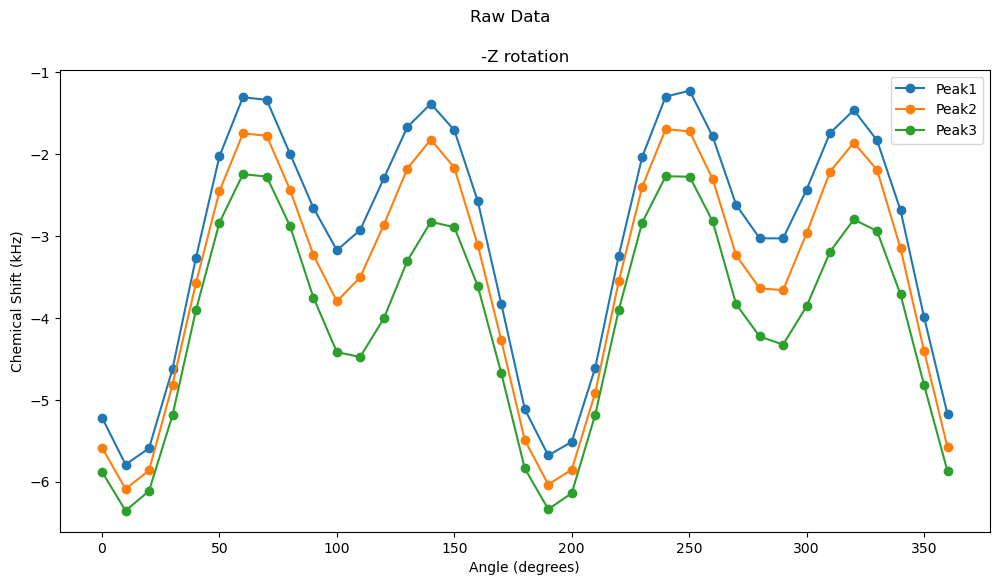

In [3]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster2Peak0 = df[i].Cluster2Peak0*w0/1000
    df[i].Cluster2Peak1 = df[i].Cluster2Peak1*w0/1000
    df[i].Cluster2Peak2 = df[i].Cluster2Peak2*w0/1000

    # print(df[i].Cluster2Peak1)
    plt.figure(figsize=(12, 6))


    plt.plot(df[i].Angle, df[i].Cluster2Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster2Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster2Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (kHz)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

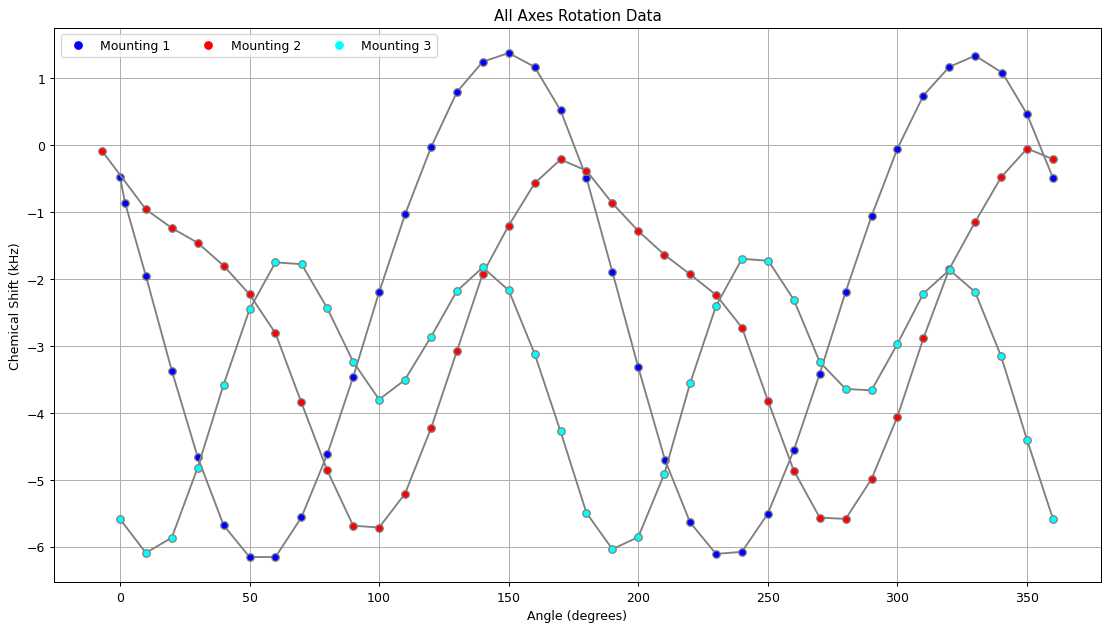

In [4]:
plt.figure(figsize = (15,8), dpi = 90)

# plt.plot(df[0].Angle, df[0].Cluster2Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster2Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster2Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster2Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster2Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='-', marker='o', color = 'grey', markerfacecolor  = 'cyan')
# plt.plot(df[2].Angle, df[2].Cluster2Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label='Mounting 3')]

# Custom legend for lines
# line_legend = [Line2D([0], [0], color='grey', lw=2, marker = '', linestyle='dotted', label='Satellite 1'),
#                Line2D([0], [0], color='grey', lw=2,marker = '', linestyle='-', label='Central'), 
#                Line2D([0], [0], color='grey', lw=2,marker = '', linestyle='--', label='Satellite 2')]

# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend 
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title('All Axes Rotation Data')
plt.xlabel('Angle (degrees)')
plt.ylabel('Chemical Shift (kHz)')
plt.grid()
plt.show()

In [5]:
# Sort eigenvalues of tensors as per the convention defined in article
def sort_eigenvalues(Tensor):
    #Calculate Quadrupolar Tensor in PAS
    eigenvalues, eigenvectors = np.linalg.eig(Tensor)
    print(' Unsorted Eigenvalues:\n', eigenvalues, '\n')
    print(' Unsorted Eigenvectors:\n', eigenvectors, '\n')

    avg_tensor = np.mean(eigenvalues) # Tr(A)Quad/3
    eigenvalue_diff = eigenvalues - avg_tensor

    # Get the indices of the sorted eigenvalues based on the absolute values
    sorted_indices = np.argsort(np.abs(eigenvalue_diff))

    # Sort both eigenvalues and eigenvectors using the sorted indices
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices] # The normalized (unit “length”) eigenvectors, 
    #                                                       such that the column eigenvectors[:,i] is the eigenvector corresponding to the eigenvalue eigenvalues[i]
    
    print('Sorted Eigenvalues: \n', sorted_eigenvalues, '\n')
    print('Sorted Eigenvectors: \n', sorted_eigenvectors, '\n')
    return sorted_eigenvalues, sorted_eigenvectors,  avg_tensor, eigenvalues, eigenvectors

**Fit Central Frequency**

R squared: 0.9998096552356951
correlation matrix:

┌───┬──────────────────────────────────────────────┐
│   │        a        b        c        d        e │
├───┼──────────────────────────────────────────────┤
│ a │        1  -0.0657 -0.00305   -0.066 -0.00444 │
│ b │  -0.0657        1 -0.00321  -0.0958 -0.00555 │
│ c │ -0.00305 -0.00321        1 -0.00111 0.000739 │
│ d │   -0.066  -0.0958 -0.00111        1 -0.00411 │
│ e │ -0.00444 -0.00555 0.000739 -0.00411        1 │
└───┴──────────────────────────────────────────────┘
covariance matrix:

┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │    0.0266  -0.00241 -0.000117  -0.00242 -0.000171 │
│ b │  -0.00241    0.0507  -0.00017  -0.00486 -0.000295 │
│ c │ -0.000117  -0.00017    0.0556 -5.89e-05  4.11e-05 │
│ d │  -0.00242  -0.00486 -5.89e-05    0.0507 -0.000218 │
│ e │ -0.000171 -0.000295  4.11e-05 -0.000218 

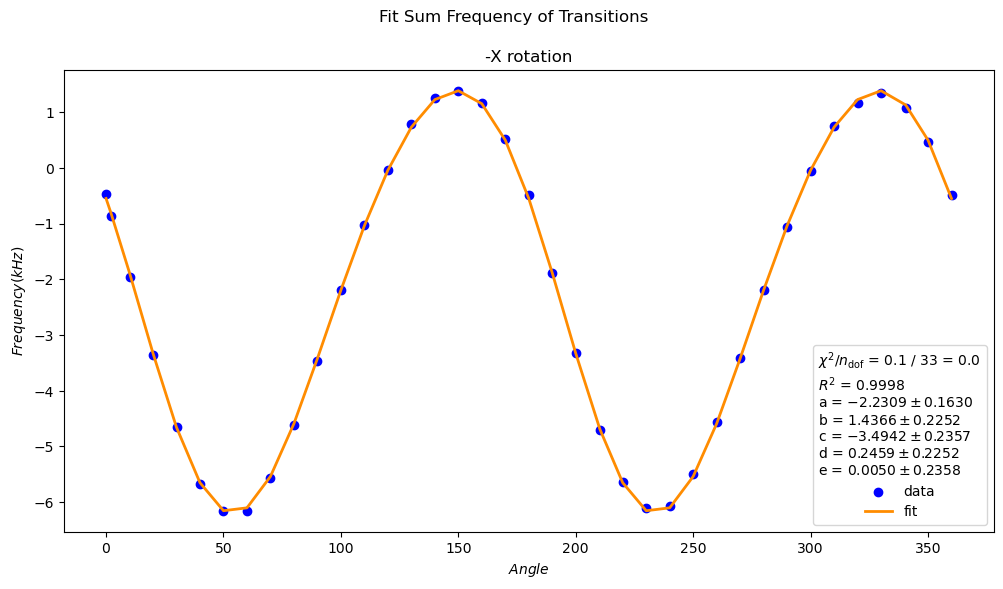

a = -2.230875396169076
b = 1.4365593415588727
c = -3.4941869195992092
d = 0.24585380994235073
e = 0.004977113604166252
R squared: 0.9928497941843328
correlation matrix:

┌───┬──────────────────────────────────────────────┐
│   │        a        b        c        d        e │
├───┼──────────────────────────────────────────────┤
│ a │        1  -0.0347  0.00846  -0.0314   0.0165 │
│ b │  -0.0347        1   0.0117  -0.0436   0.0229 │
│ c │  0.00846   0.0117        1   0.0106 -0.00558 │
│ d │  -0.0314  -0.0436   0.0106        1   0.0207 │
│ e │   0.0165   0.0229 -0.00558   0.0207        1 │
└───┴──────────────────────────────────────────────┘
covariance matrix:

┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │    0.0271  -0.00131  0.000328   -0.0012  0.000636 │
│ b │  -0.00131     0.053  0.000636  -0.00232   0.00123 │
│ c │  0.000328  0.000636    0.0554  0.0005

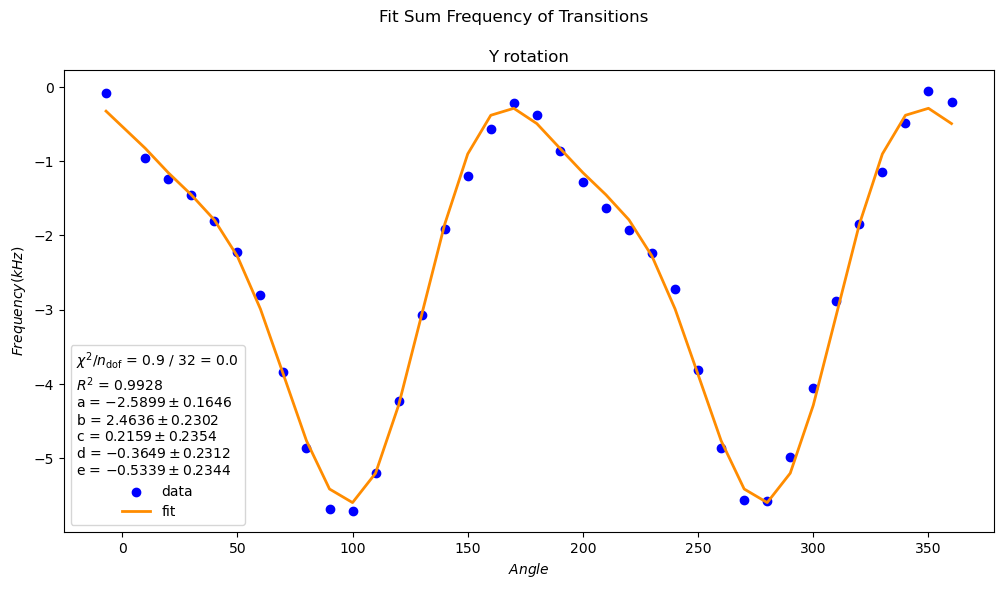

a = -2.589889049700719
b = 2.4635850491517846
c = 0.2158693471022865
d = -0.36488058385634037
e = -0.533906362824278
R squared: 0.9975467653910693
correlation matrix:

┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0356   0.00019    -0.037  0.000141 │
│ b │   -0.0356         1  0.000116   -0.0499 -3.33e-05 │
│ c │   0.00019  0.000116         1 -0.000277  -0.00111 │
│ d │    -0.037   -0.0499 -0.000277         1  0.000414 │
│ e │  0.000141 -3.33e-05  -0.00111  0.000414         1 │
└───┴───────────────────────────────────────────────────┘
covariance matrix:

┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │    0.0271  -0.00135  7.38e-06   -0.0014  5.47e-06 │
│ b │  -0.00135    0.0528  6.28e-06  -0.00263  -1.8e-06 │


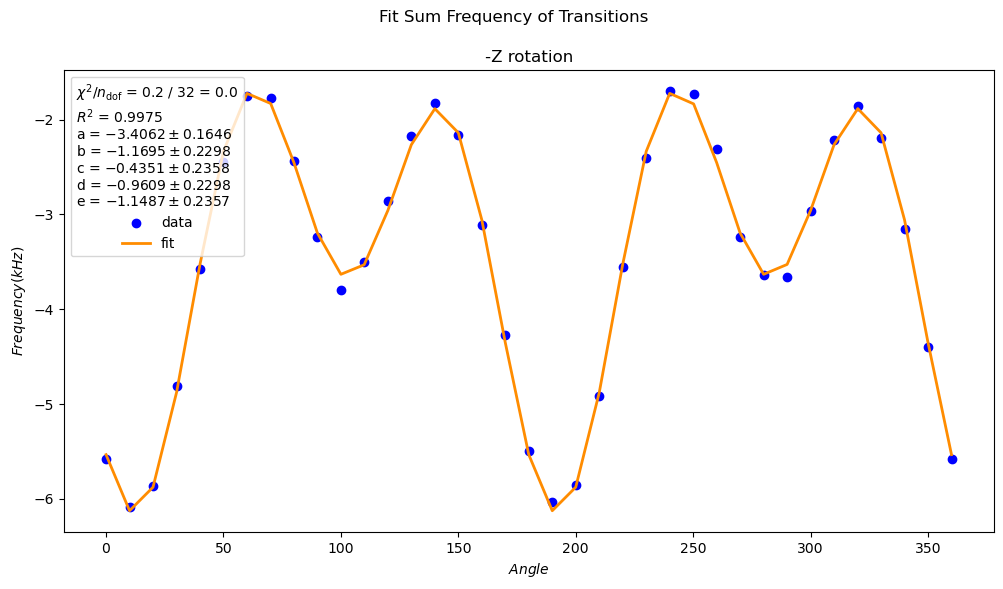

a = -3.406234860207289
b = -1.1694754727621979
c = -0.4350649132710172
d = -0.9609236511890868
e = -1.1486508372336606


In [6]:
m = [0]*3
corr_mat = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, df[i].Cluster2Peak1, 1, fourier5)
    
    m[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    m[i].migrad()  # finds minimum of least_squares function
    m[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m[i].fval:.1f} / {m[i].ndof:.0f} = {m[i].fmin.reduced_chi2:.1f}",
    ]

    # Calculate R squared

    y_true = df[i].Cluster2Peak1
    y_pred = fourier5(df[i].Angle, *m[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

    fit_info.append(f"$R^2$ = {R_squared:.4f}")
    
    for p, v, e in zip(m[i].parameters, m[i].values, m[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m[i].covariance.correlation())
    cov_mat = (m[i].covariance)
    print('correlation matrix:\n')
    print(corr_mat)
    print('covariance matrix:\n')
    print(cov_mat)
    print('Chi square:', m[i].fval)
    print(m[i].migrad())


    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, df[i].Cluster2Peak1, label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m[i].values), label="fit", lw = 2, color = 'darkorange')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (kHz)$')

    # Titles
    plt.suptitle('Fit Sum Frequency of Transitions')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))

    # plt.grid()
    plt.show()
    for key, value in zip(m[i].parameters, m[i].values):
        print(f"{key} = {value}")

In [7]:
A_coeff = []; B_coeff = []; C_coeff = []; D_coeff = []; E_coeff = []
for i in range(len(m)):  # Or directly 'for i in range(len(m))' if the length isn't fixed
    A_coeff_val, B_coeff_val, C_coeff_val, D_coeff_val, E_coeff_val = m[i].values[:5]
    A_coeff.append(A_coeff_val); 
    B_coeff.append(B_coeff_val); 
    C_coeff.append(C_coeff_val); 
    D_coeff.append(D_coeff_val); 
    E_coeff.append(E_coeff_val)

In [8]:
# Provide input values

#constants for 11B nuclei
Ispin = 3/2
w0 = 192.55 #Larmor Frequency for 11B (MHz)
wkhz = w0*10**3 # LArmor frequency in Hz

#factor q given in article
q = (3-4*Ispin*(Ispin + 1))/(16*(wkhz))

**Solving Quadratic equations to find Quad and CS tensor components**

In [9]:
#Define symbol for quadrupolar tensor and force them to be real
AzzmAyy_Q,AzzmAxx_Q,AyymAxx_Q,Ayz_Q,Axz_Q,Axy_Q = sym.symbols('AzzmAyy_Q,AzzmAxx_Q,AyymAxx_Q,Ayz_Q,Axz_Q,Axy_Q', real=True)

#Variable for each equation set
quad_tensor = [(AzzmAyy_Q, Ayz_Q), (AzzmAxx_Q, Axz_Q), (AyymAxx_Q, Axy_Q)]

# List to hold solutions for quadrupolar tensor terms
solutions_Q = []

for i, (diagonal_diff, off_diagonal) in enumerate(quad_tensor):
    
    eq1 = sym.Eq(-((diagonal_diff)**2 - 4*(off_diagonal)**2)*((9*q/8)), D_coeff[i])
    eq2 = sym.Eq(off_diagonal*(diagonal_diff)*(9*q/2), E_coeff[i])

    # Solve the system
    solution = sym.solve([eq1, eq2], (diagonal_diff, off_diagonal))
    solutions_Q.append(solution)

# Assign the solutions to the respective variables
AzzmAyy_Q = [solutions_Q[0][0][0], solutions_Q[0][1][0]]
Ayz_Q = [solutions_Q[0][0][1], solutions_Q[0][1][1]]
AzzmAxx_Q = [solutions_Q[1][0][0], solutions_Q[1][1][0]]
Axz_Q = [solutions_Q[1][0][1], solutions_Q[1][1][1]]
AyymAxx_Q = [solutions_Q[2][0][0], solutions_Q[2][1][0]]
Axy_Q = [solutions_Q[2][0][1], solutions_Q[2][1][1]]

# print(solutions_Q)
# Print the final results for the variables
print(f"Azz - Ayy: {AzzmAyy_Q}, Ayz: {Ayz_Q}")
print(f"Azz - Axx: {AzzmAxx_Q}, Axz: {Axz_Q}")
print(f"Ayy - Axx: {AyymAxx_Q}, Axy: {Axy_Q}") 

Azz - Ayy: [-236.878467555918, 236.878467555918], Ayz: [1.19873093964397, -1.19873093964397]
Azz - Axx: [-179.316070632517, 179.316070632517], Axz: [-169.869586184698, 169.869586184698]
Ayy - Axx: [-247.458100351719, 247.458100351719], Axy: [-264.823246045359, 264.823246045359]


In [10]:
import itertools
# Generate all combinations of AzzmAxx, AyymAxx, and AzzmAyy
combinations = list(itertools.product(AzzmAxx_Q, AyymAxx_Q, AzzmAyy_Q))
print('Combination of (Azz - Axx), (Ayy - Axx), (Azz - Ayy): \n ', combinations)

Combination of (Azz - Axx), (Ayy - Axx), (Azz - Ayy): 
  [(-179.316070632517, -247.458100351719, -236.878467555918), (-179.316070632517, -247.458100351719, 236.878467555918), (-179.316070632517, 247.458100351719, -236.878467555918), (-179.316070632517, 247.458100351719, 236.878467555918), (179.316070632517, -247.458100351719, -236.878467555918), (179.316070632517, -247.458100351719, 236.878467555918), (179.316070632517, 247.458100351719, -236.878467555918), (179.316070632517, 247.458100351719, 236.878467555918)]


In [11]:

#Find Quadrupolar tensor diagonal elements

Axx1 = []; Axx2 = []; Axx3 = []
Ayy1 = []; Ayy2 = []; Ayy3 = []
Azz1 = []; Azz2 = []; Azz3 = []

# Initialize variables to track the best combination and minimum variation
best_combination = None
min_variation = float('inf')
for (AzzmAxx_val, AyymAxx_val, AzzmAyy_val) in combinations:
    # Solution 1
    Axx1_val = (-(AzzmAxx_val + AyymAxx_val)/3)
    Ayy1_val = Axx1_val + AyymAxx_val
    Azz1_val = Axx1_val + AzzmAxx_val

    #Save values
    Axx1.append(Axx1_val)
    Ayy1.append(Ayy1_val)
    Azz1.append(Azz1_val)

     # Solution 2
    Ayy2_val = -(AzzmAyy_val - AyymAxx_val) / 3
    Axx2_val = Ayy2_val - AyymAxx_val
    Azz2_val = Ayy2_val + AzzmAyy_val

     #Save values
    Axx2.append(Axx2_val)
    Ayy2.append(Ayy2_val)
    Azz2.append(Azz2_val)

    # Solution 3
    Azz3_val = (AzzmAxx_val + AzzmAyy_val) / 3
    Axx3_val = Azz3_val - AzzmAxx_val
    Ayy3_val = Azz3_val - AzzmAyy_val
    
    #Save values
    Axx3.append(Axx3_val)
    Ayy3.append(Ayy3_val)
    Azz3.append(Azz3_val)

    # Convert sympy Float to regular Python float for NumPy functions
    Axx1_val = float(Axx1_val)
    Axx2_val = float(Axx2_val)
    Axx3_val = float(Axx3_val)
    
    Ayy1_val = float(Ayy1_val)
    Ayy2_val = float(Ayy2_val)
    Ayy3_val = float(Ayy3_val)
    
    Azz1_val = float(Azz1_val)
    Azz2_val = float(Azz2_val)
    Azz3_val = float(Azz3_val)

    # Calculate variation (standard deviation) for Axx, Ayy, Azz
    variation_Axx = np.std([Axx1_val, Axx2_val, Axx3_val])
    variation_Ayy = np.std([Ayy1_val, Ayy2_val, Ayy3_val])
    variation_Azz = np.std([Azz1_val, Azz2_val, Azz3_val])

    total_variation = variation_Axx + variation_Ayy + variation_Azz

    # Update the best combination if the current one has less variation
    if total_variation < min_variation:
        min_variation = total_variation
        best_combination = (AzzmAxx_val, AyymAxx_val, AzzmAyy_val)
        best_Axx_Q = np.mean([Axx1_val, Axx2_val, Axx3_val])
        best_Ayy_Q = np.mean([Ayy1_val, Ayy2_val, Ayy3_val])
        best_Azz_Q = np.mean([Azz1_val, Azz2_val, Azz3_val])

#Get index for off-diagonal elements        
index_AzzmAxx = AzzmAxx_Q.index(best_combination[0])
best_Axz_Q = Axz_Q[index_AzzmAxx]

index_AyymAxx = AyymAxx_Q.index(best_combination[1])
best_Axy_Q = Axy_Q[index_AyymAxx]

index_AzzmAyy = AzzmAyy_Q.index(best_combination[2])
best_Ayz_Q = Ayz_Q[index_AzzmAyy]

# Print results
print("Axx1:", Axx1)
print("Axx2:", Axx2)
print("Axx3:", Axx3)

print("Ayy1:", Ayy1)
print("Ayy2:", Ayy2)
print("Ayy3:", Ayy3)

print("Azz1:", Azz1)
print("Azz2:", Azz2)
print("Azz3:", Azz3)

print("Best combination with minimum standard deviation:")
print("AzzmAxx:", best_combination[0])
print("AyymAxx:", best_combination[1])
print("AzzmAyy:", best_combination[2])


print("Axz:", best_Axz_Q)
print("Axy:", best_Axy_Q)
print("Ayz:", best_Ayz_Q)

print("Average of Axx1, Axx2, Axx3 with minimum standard deviation:", best_Axx_Q)
print("Average of Ayy1, Ayy2, Ayy3 with minimum standard deviation:", best_Ayy_Q)
print("Average of Azz1, Azz2, Azz3 with minimum standard deviation:", best_Azz_Q)




Axx1: [142.258056994745, 142.258056994745, -22.7140099064006, -22.7140099064006, 22.7140099064006, 22.7140099064006, -142.258056994745, -142.258056994745]
Axx2: [243.931556086452, 86.0125777158399, -86.0125777158399, -243.931556086452, 243.931556086452, 86.0125777158399, -86.0125777158399, -243.931556086452]
Axx3: [40.5845579030387, 198.503536273651, 40.5845579030387, 198.503536273651, -198.503536273651, -40.5845579030387, -198.503536273651, -40.5845579030387]
Ayy1: [-105.200043356974, -105.200043356974, 224.744090445318, 224.744090445318, -224.744090445318, -224.744090445318, 105.200043356974, 105.200043356974]
Ayy2: [-3.52654426526700, -161.445522635879, 161.445522635879, 3.52654426526700, -3.52654426526700, -161.445522635879, 161.445522635879, 3.52654426526700]
Ayy3: [98.1469548264395, -217.691001914784, 98.1469548264395, -217.691001914784, 217.691001914784, -98.1469548264395, 217.691001914784, -98.1469548264395]
Azz1: [-37.0580136377717, -37.0580136377717, -202.030080538918, -202.0

In [12]:
#Define symbol for CSA tensor and force them to be real
Azz_s, Axx_s, Ayy_s, Ayz_s, Axz_s, Axy_s = sym.symbols('Azz_s,Axx_s,Ayy_s,Ayz_s,Axz_s,Axy_s', real=True)

#Variables for each equation
cs_tensor = [(Ayy_s, Azz_s, Ayz_s), # for x -> Abb = Ayy; Agg = Azz; Abg = Ayz
             (Axx_s, Azz_s, Axz_s), # for y -> Abb = Axx; Agg = Azz; Abg = Axz
             (Axx_s, Ayy_s, Axy_s)] # for z -> Abb = Axx; Agg = Ayy; Abg = Axy

#Store variables in dictionary for access
A = {
    'xx': best_Axx_Q, 'yy': best_Ayy_Q, 'zz': best_Azz_Q,
    'yz': best_Ayz_Q, 'zy': best_Ayz_Q,
    'xz': best_Axz_Q, 'zx': best_Axz_Q,
    'xy': best_Axy_Q, 'yx': best_Axy_Q,
}

#Define rotation tuple (a, b, g, bg, m)
rotations = [
    ('x', 'y', 'z', 'yz', 1),   # a = x, b = y, g = z, m = 1
    ('y', 'x', 'z', 'xz', 1),  # a = y, b = x, g = z, m = 1
    ('z', 'x', 'y', 'xy', -1)  # a = z, b = x, g = y, m = -1
]

# List to hold solutions
solutions_cs = []

for i, (Abb_s, Agg_s, Abg_s) in enumerate(cs_tensor):
    a, b, g, bg, m = rotations[i]
    eq1 = sym.Eq(
        (8*A[a+a]*(A[b+b] + A[g+g] - A[a+a]) + 16*(A[a+b]**2 + A[a+g]**2) + 5*(A[b+b]**2 + A[g+g]**2) + 28*A[b+g]**2 - 18*A[b+b]*A[g+g])*(q/8) - 0.5*(Abb_s + Agg_s)*wkhz, A_coeff[i]
        )
    
    eq2 = sym.Eq(
        m*(2*A[a+a]*(A[b+b] - A[g+g]) - 12*(A[a+b]**2 - A[a+g]**2) - A[b+b]**2 + A[g+g]**2)*(q/2) - 0.5*m*(Agg_s - Abb_s)*wkhz, B_coeff[i]
        )
    
    eq3 = sym.Eq(
        -m*(-2*A[a+a]*A[b+g] + 12*A[a+b]*A[a+g] + A[b+g]*(A[b+b] + A[g+g]))*q - m*Abg_s*wkhz, C_coeff[i]
    )
    # Solve the system
    solution = sym.solve([eq1, eq2, eq3], (Abb_s, Agg_s, Abg_s))
    solutions_cs.append(solution)

print(solutions_cs)

#saving solutions
Axx_s = np.mean([solutions_cs[1][Axx_s], solutions_cs[2][Axx_s]])
Ayy_s = np.mean([solutions_cs[0][Ayy_s], solutions_cs[2][Ayy_s]])
Azz_s = np.mean([solutions_cs[0][Azz_s], solutions_cs[1][Azz_s]])

Ayz_s = solutions_cs[0][Ayz_s]
Axz_s = solutions_cs[1][Axz_s]
Axy_s = solutions_cs[2][Axy_s]

print('Axx_s, Ayy_s, Azz_s, Ayz_s, Axz_s, Axy_s: \n', Axx_s, Ayy_s, Azz_s, Ayz_s, Axz_s, Axy_s)


[{Ayy_s: 9.59580724172731e-6, Azz_s: 6.25341683050858e-6, Ayz_s: 2.90773703979171e-5}, {Axx_s: 1.31679387401014e-5, Azz_s: 5.80858658169953e-6, Axz_s: -2.70836830035795e-6}, {Axx_s: 1.26896641900008e-5, Ayy_s: 7.19308919774588e-6, Axy_s: -1.90169242048176e-6}]
Axx_s, Ayy_s, Azz_s, Ayz_s, Axz_s, Axy_s: 
 1.29288014650511e-5 8.39444821973659e-6 6.03100170610405e-6 2.90773703979171e-5 -2.70836830035795e-6 -1.90169242048176e-6


In [13]:
#Quadrupolar Tensor in Tenon Frame
Q_T = np.zeros((3,3))
Q_T[0,0] = best_Axx_Q; Q_T[0,1] = best_Axy_Q; Q_T[0,2] = best_Axz_Q;
Q_T[1,0] = best_Axy_Q; Q_T[1,1] = best_Ayy_Q; Q_T[1,2] = best_Ayz_Q;
Q_T[2,0] = best_Axz_Q; Q_T[2,1] = best_Ayz_Q; Q_T[2,2] = best_Azz_Q;



#CSA tensor in tenon frame
CS_T = np.zeros((3,3))
CS_T[0,0] = Axx_s; CS_T[0,1] = Axy_s; CS_T[0,2] = Axz_s;
CS_T[1,0] = Axy_s; CS_T[1,1] = Ayy_s; CS_T[1,2] = Ayz_s;
CS_T[2,0] = Axz_s; CS_T[2,1] = Ayz_s; CS_T[2,2] = Azz_s;

print('Chemical Shift tensor (tenon frame): \n', CS_T, '\n')
print('Quadrupolar tensor (MHz) (tenon frame): \n', Q_T/10**3, '\n')

Chemical Shift tensor (tenon frame): 
 [[ 1.29288015e-05 -1.90169242e-06 -2.70836830e-06]
 [-1.90169242e-06  8.39444822e-06  2.90773704e-05]
 [-2.70836830e-06  2.90773704e-05  6.03100171e-06]] 

Quadrupolar tensor (MHz) (tenon frame): 
 [[ 0.14225806 -0.26482325 -0.16986959]
 [-0.26482325 -0.16144552 -0.00119873]
 [-0.16986959 -0.00119873  0.01918747]] 



In [14]:
#following the Voseggard et al. paper for principal frame parameters JOURNAL OF MAGNETIC RESONANCE, Series A 122, 111 – 119 ( 1996 ) ARTICLE NO. 0186

#Calculate Quadrupolar Tensor in PAS

sorted_eigenvalues_Q, sorted_eigenvectors_Q, quad_avg, eigenvalues_Q, eigenvectors_Q = sort_eigenvalues(Q_T)
# print('Sorted Eigenvalues of Quadrupolar diagonal matrix (|Ayy - Tr(A)/3| <= |Axx - Tr(A)/3| <= |Azz - Tr(A)/3|):\n', sorted_eigenvalues_Q, '\n') 

Vyy = (sorted_eigenvalues_Q[0])*(2*Ispin*(2*Ispin - 1)) 
Vxx = (sorted_eigenvalues_Q[1])*(2*Ispin*(2*Ispin - 1))
Vzz = (sorted_eigenvalues_Q[2])*(2*Ispin*(2*Ispin - 1)) 

print('Quadupolar Tensor Components Vyy, Vxx, Vzz: \n', Vyy, Vxx, Vzz)

print('================================================================================================ \n')

#Calculate CSA Tensor in PAS

sorted_eigenvalues_csa, sorted_eigenvectors_csa, csa_avg, eigenvalues_csa, eigenvectors_csa = sort_eigenvalues(CS_T)
# print('Sorted Eigenvalues of CSA diagonal matrix (|Ayy - Tr(A)/3| <= |Axx - Tr(A)/3| <= |Azz - Tr(A)/3|):\n', sorted_eigenvalues_csa, '\n') 

csyy = -(sorted_eigenvalues_csa[0]) 
csxx = -(sorted_eigenvalues_csa[1])
cszz = -(sorted_eigenvalues_csa[2]) 

print('CSA Tensor Components δyy, δxx, δzz: \n', csyy, csxx, cszz)



 Unsorted Eigenvalues:
 [ 360.54190613 -337.84855476  -22.69335137] 

 Unsorted Eigenvectors:
 [[-0.81592299  0.53492475  0.21937452]
 [ 0.41301836  0.80479814 -0.42628136]
 [ 0.40458065  0.25720705  0.87758705]] 

Sorted Eigenvalues: 
 [ -22.69335137 -337.84855476  360.54190613] 

Sorted Eigenvectors: 
 [[ 0.21937452  0.53492475 -0.81592299]
 [-0.42628136  0.80479814  0.41301836]
 [ 0.87758705  0.25720705  0.40458065]] 

Quadupolar Tensor Components Vyy, Vxx, Vzz: 
 -136.160108240443 -2027.091328531596 2163.2514367720382

 Unsorted Eigenvalues:
 [ 3.67568389e-05  1.24977534e-05 -2.19003409e-05] 

 Unsorted Eigenvectors:
 [[ 0.13508094 -0.99066432  0.01836702]
 [-0.71369332 -0.11013989 -0.69174493]
 [-0.68730996 -0.08033314  0.72190831]] 

Sorted Eigenvalues: 
 [ 1.24977534e-05  3.67568389e-05 -2.19003409e-05] 

Sorted Eigenvectors: 
 [[-0.99066432  0.13508094  0.01836702]
 [-0.11013989 -0.71369332 -0.69174493]
 [-0.08033314 -0.68730996  0.72190831]] 

CSA Tensor Components δyy, δxx, δ

In [15]:
#Quadrupolar tensor parameters
cq = Vzz/10**3
etaq = (Vyy - Vxx)/Vzz

#CSA tensor parameters
iso_cs = np.mean([cszz, csyy, csxx]) 
csa = cszz - iso_cs

etas = (csyy - csxx)/csa


table = [['cq (MHz)', cq], ['etaq', etaq ], ['iso_cs (ppm)', iso_cs*10**6], ['csa (ppm)', csa*10**6], ['etas', etas] ] #converting Hz to ppm (Should be multiplied by 10**6)
print(tabulate(table, headers=['Quantity', 'Fit Value']))

Quantity        Fit Value
------------  -----------
cq (MHz)         2.16325
etaq             0.874115
iso_cs (ppm)    -9.11808
csa (ppm)       31.0184
etas             0.782086
